<a href="https://colab.research.google.com/github/sankalp120/machinelearning/blob/main/mllab_17_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import libraries
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temp": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
             "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal",
                 "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
             "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "Golf Players": [25,30,46,45,52,23,43,35,38,46,48,52,44,30]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
# Step 3: Encode categorical features
label_encoders = {}
for column in ["Outlook", "Temp", "Humidity", "Wind"]:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [5]:
# Step 4: Split features and target
X = df[["Outlook", "Temp", "Humidity", "Wind"]]
y = df["Golf Players"]

In [6]:
# Step 5: Train Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X, y)

DecisionTreeRegressor(random_state=42)

In [7]:
# Step 6: Predict for a new sample
# Example: Outlook=Rain, Temp=Mild, Humidity=Normal, Wind=Weak
new_sample = pd.DataFrame({
    "Outlook": [label_encoders["Outlook"].transform(["Rain"])[0]],
    "Temp": [label_encoders["Temp"].transform(["Mild"])[0]],
    "Humidity": [label_encoders["Humidity"].transform(["Normal"])[0]],
    "Wind": [label_encoders["Wind"].transform(["Weak"])[0]]
})

In [8]:
prediction = model.predict(new_sample)
print("Predicted number of Golf Players:", prediction[0])

Predicted number of Golf Players: 46.0


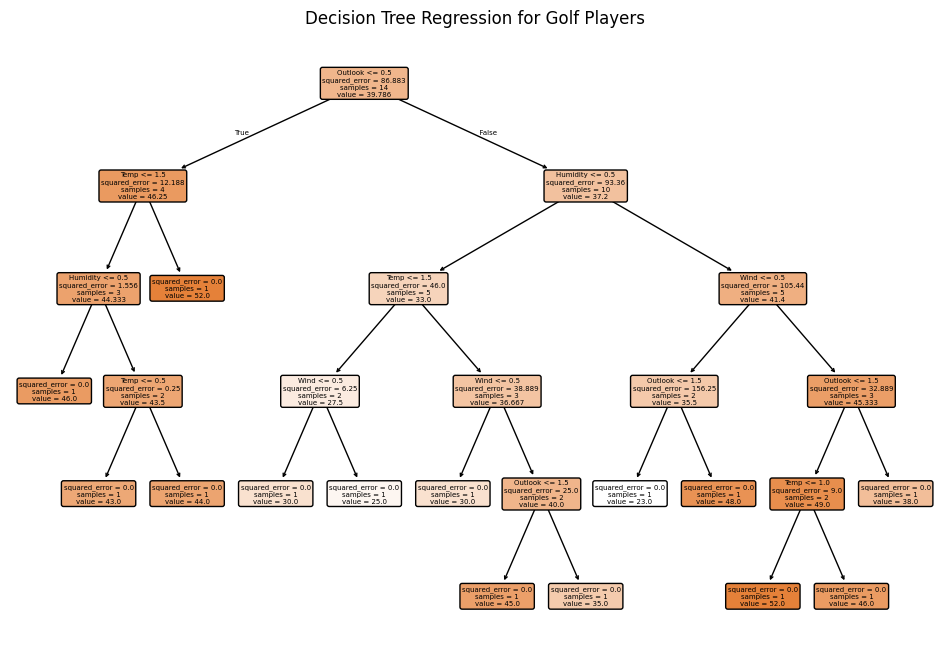

In [9]:
# Step 7: Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(model,
          feature_names=X.columns,
          filled=True,
          rounded=True)
plt.title("Decision Tree Regression for Golf Players")
plt.show()

In [12]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import requests # Import requests for downloading files

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Column names as per UCI IRIS dataset
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

# Define the path for the dataset in the Colab environment
data_dir = "data"
iris_file_name = "iris.data"
iris_data_path = os.path.join(data_dir, iris_file_name)

# Check if the directory and file exist, if not, download it
if not os.path.exists(iris_data_path):
    print(f"'{iris_data_path}' not found. Attempting to download...")
    os.makedirs(data_dir, exist_ok=True)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(iris_data_path, "wb") as f:
            f.write(response.content)
        print("Iris dataset downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading Iris dataset: {e}")
        # You might want to handle this error more gracefully, e.g., exit or use a fallback
        raise # Re-raise the exception after printing

# Load the IRIS Dataset (NO HEADER in iris.data)
data = pd.read_csv(iris_data_path, header=None, names=columns)

# Remove possible empty rows (sometimes last line is blank)
data.dropna(inplace=True)

# Features and target
X = data.drop("species", axis=1)
y = data["species"]

print("Dataset shape:", data.shape)
print(data.head())

# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ---------------- Naïve Bayes ----------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Naïve Bayes Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

# ---------------- Decision Tree ----------------
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# ---------------- Model Comparison ----------------
print("Model Comparison")
print("----------------")
print(f"Naïve Bayes Accuracy    : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Decision Tree Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")

'data/iris.data' not found. Attempting to download...
Iris dataset downloaded successfully.
Dataset shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
=== Naïve Bayes Classifier ===
Accuracy: 0.9210526315789473

Confusion Matrix:
 [[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.86      0.92      0.89        13
 Iris-virginica       0.92      0.85      0.88        13

       accuracy                           0.92        38
      macro avg       0.92      0.92     